# Sorting and Binary Search: Ordering Before Speed

Sorting is one of the first places where algorithm design becomes visible.

Long before computers, people sorted names, ledgers, books, specimens, and census records because order turns a pile into something searchable. In modern systems the same idea sits underneath databases, search engines, spreadsheets, graphics pipelines, and file indexes.

The same list can be sorted by:

- repeatedly swapping neighbors,
- recursively splitting and merging,
- choosing pivots and partitioning.

Once data is sorted, binary search can find items by cutting the search space in half again and again.

## 1. Mental Model

Sorting is about turning messy data into a predictable shape.

Binary search is the reward for doing that work:

> if the list is sorted, one comparison can discard half the remaining possibilities.

<details>
<summary>Order as infrastructure</summary>

Many later algorithms assume order: searching, merging datasets, scheduling, ranking, compression, and graph priority queues. Sorting is not just a beginner topic; it is infrastructure.
</details>

## 2. What We Will Build

We will compare four classic tools:

- `Bubble Sort`: simple, visual, slow on large lists.
- `Merge Sort`: split, sort, merge; predictable $O(n \log n)$ time.
- `Quick Sort`: choose a pivot, partition, recurse; fast in practice.
- `Binary Search`: search a sorted list in $O(\log n)$ time.

The code records steps so we can replay what the algorithms actually did.

**Trace model.** Define `SortStep`, the structure used to capture replayable algorithm state.


In [ ]:
from dataclasses import dataclass

import matplotlib.pyplot as plt

@dataclass(frozen=True)
class SortStep:
    algorithm: str
    values: tuple[int, ...]
    message: str
    active_indices: tuple[int, ...] = ()
    depth: int = 0


**Object model.** Define `SortResult`, the named objects used by the next examples.


In [ ]:
@dataclass(frozen=True)
class SortResult:
    algorithm: str
    original: tuple[int, ...]
    sorted_values: tuple[int, ...]
    steps: list[SortStep]
    comparisons: int
    writes: int

    def summary(self) -> str:
        return (
            f"{self.algorithm:<12} sorted={list(self.sorted_values)} "
            f"comparisons={self.comparisons:<3} writes={self.writes:<3} steps={len(self.steps)}"
        )


**Trace model.** Define `SearchStep`, `SearchResult`, the structure used to capture replayable algorithm state.


In [ ]:
@dataclass(frozen=True)
class SearchStep:
    low: int
    high: int
    mid: int
    guess: int
    decision: str

    def describe(self) -> str:
        return f"low={self.low}, high={self.high}, mid={self.mid}, guess={self.guess}: {self.decision}"

@dataclass(frozen=True)
class SearchResult:
    values: tuple[int, ...]
    target: int
    found_index: int | None
    steps: list[SearchStep]

    def summary(self) -> str:
        location = "not found" if self.found_index is None else f"index {self.found_index}"
        return f"target {self.target} -> {location} in {len(self.steps)} comparisons"


**Algorithm engine.** Define `SortingWorkshop`, the class that runs the main simulation or algorithm.


In [ ]:
class SortingWorkshop:
    def bubble_sort(self, values: list[int]) -> SortResult:
        numbers = values[:]
        steps = [SortStep("Bubble", tuple(numbers), "start")]
        comparisons = 0
        writes = 0

        for pass_index in range(len(numbers) - 1):
            swapped = False
            for index in range(len(numbers) - 1 - pass_index):
                comparisons += 1
                steps.append(
                    SortStep("Bubble", tuple(numbers), f"compare positions {index} and {index + 1}", (index, index + 1))
                )
                if numbers[index] > numbers[index + 1]:
                    numbers[index], numbers[index + 1] = numbers[index + 1], numbers[index]
                    writes += 2
                    swapped = True
                    steps.append(
                        SortStep("Bubble", tuple(numbers), f"swap into order", (index, index + 1))
                    )
            if not swapped:
                steps.append(SortStep("Bubble", tuple(numbers), "stop early: no swaps"))
                break

        return SortResult("Bubble", tuple(values), tuple(numbers), steps, comparisons, writes)

    def merge_sort(self, values: list[int]) -> SortResult:
        steps: list[SortStep] = [SortStep("Merge", tuple(values), "start")]
        comparisons = 0
        writes = 0

        def split_and_merge(items: list[int], depth: int = 0) -> list[int]:
            nonlocal comparisons, writes
            if len(items) <= 1:
                return items[:]

            middle = len(items) // 2
            left = split_and_merge(items[:middle], depth + 1)
            right = split_and_merge(items[middle:], depth + 1)
            merged: list[int] = []
            left_index = 0
            right_index = 0

            while left_index < len(left) and right_index < len(right):
                comparisons += 1
                if left[left_index] <= right[right_index]:
                    merged.append(left[left_index])
                    left_index += 1
                else:
                    merged.append(right[right_index])
                    right_index += 1
                writes += 1

            merged.extend(left[left_index:])
            merged.extend(right[right_index:])
            writes += len(left) - left_index + len(right) - right_index
            steps.append(
                SortStep("Merge", tuple(merged), f"merge {left} and {right} -> {merged}", depth=depth)
            )
            return merged

        sorted_values = split_and_merge(values)
        steps.append(SortStep("Merge", tuple(sorted_values), "done"))
        return SortResult("Merge", tuple(values), tuple(sorted_values), steps, comparisons, writes)

    def quick_sort(self, values: list[int]) -> SortResult:
        steps: list[SortStep] = [SortStep("Quick", tuple(values), "start")]
        comparisons = 0
        writes = 0

        def partition(items: list[int], depth: int = 0) -> list[int]:
            nonlocal comparisons, writes
            if len(items) <= 1:
                return items[:]

            pivot = items[-1]
            smaller: list[int] = []
            equal: list[int] = []
            larger: list[int] = []

            for number in items:
                comparisons += 1
                if number < pivot:
                    smaller.append(number)
                elif number > pivot:
                    larger.append(number)
                else:
                    equal.append(number)
                writes += 1

            steps.append(
                SortStep("Quick", tuple(smaller + equal + larger), f"pivot {pivot}: {smaller} | {equal} | {larger}", depth=depth)
            )
            return partition(smaller, depth + 1) + equal + partition(larger, depth + 1)

        sorted_values = partition(values)
        steps.append(SortStep("Quick", tuple(sorted_values), "done"))
        return SortResult("Quick", tuple(values), tuple(sorted_values), steps, comparisons, writes)

    def binary_search(self, values: list[int], target: int) -> SearchResult:
        low = 0
        high = len(values) - 1
        steps: list[SearchStep] = []

        while low <= high:
            mid = (low + high) // 2
            guess = values[mid]
            if guess == target:
                steps.append(SearchStep(low, high, mid, guess, "found"))
                return SearchResult(tuple(values), target, mid, steps)
            if guess < target:
                steps.append(SearchStep(low, high, mid, guess, "too small; keep right half"))
                low = mid + 1
            else:
                steps.append(SearchStep(low, high, mid, guess, "too large; keep left half"))
                high = mid - 1

        return SearchResult(tuple(values), target, None, steps)


**Trace model.** Define `SortReplay`, the structure used to capture replayable algorithm state.


In [ ]:
class SortReplay:
    def __init__(self, result: SortResult):
        self.result = result

    def show(self, max_steps: int = 10) -> None:
        for step_number, step in enumerate(self.result.steps[:max_steps], start=1):
            indent = "  " * step.depth
            print(f"{step_number:>2}. {indent}{step.message}: {list(step.values)}")
        if len(self.result.steps) > max_steps:
            print(f"... {len(self.result.steps) - max_steps} more steps")


**Visual helper.** Define `plot_sort_snapshot`, which turns state into something students can inspect.


In [ ]:
def plot_sort_snapshot(step: SortStep, title: str | None = None) -> None:
    colors = ["#3CAEA3" for _ in step.values]
    for index in step.active_indices:
        if 0 <= index < len(colors):
            colors[index] = "#D95D39"

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(range(len(step.values)), step.values, color=colors, edgecolor="#1F2933")
    ax.set_xticks(range(len(step.values)))
    ax.set_title(title or step.message)
    ax.set_xlabel("position")
    ax.set_ylabel("value")
    plt.tight_layout()
    plt.show()


**Visual helper.** Define `plot_algorithm_costs`, which turns state into something students can inspect.


In [ ]:
def plot_algorithm_costs(results: list[SortResult]) -> None:
    names = [result.algorithm for result in results]
    comparisons = [result.comparisons for result in results]
    writes = [result.writes for result in results]

    fig, ax = plt.subplots(figsize=(7, 4))
    x_positions = range(len(results))
    ax.bar([x - 0.18 for x in x_positions], comparisons, width=0.36, label="comparisons", color="#20639B")
    ax.bar([x + 0.18 for x in x_positions], writes, width=0.36, label="writes", color="#F6D55C", edgecolor="#1F2933")
    ax.set_xticks(list(x_positions), names)
    ax.set_title("work done on the same input")
    ax.set_ylabel("count")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 3. Run Three Sorts on the Same List

Using the same input makes the tradeoffs easier to see.

Bubble sort is simple but does lots of neighbor checks. Merge sort and quicksort both use divide-and-conquer, but they split the problem in different ways.

Bubble       sorted=[2, 3, 4, 5, 6, 7, 8, 9] comparisons=27  writes=32  steps=45
Merge        sorted=[2, 3, 4, 5, 6, 7, 8, 9] comparisons=17  writes=24  steps=9
Quick        sorted=[2, 3, 4, 5, 6, 7, 8, 9] comparisons=22  writes=22  steps=8


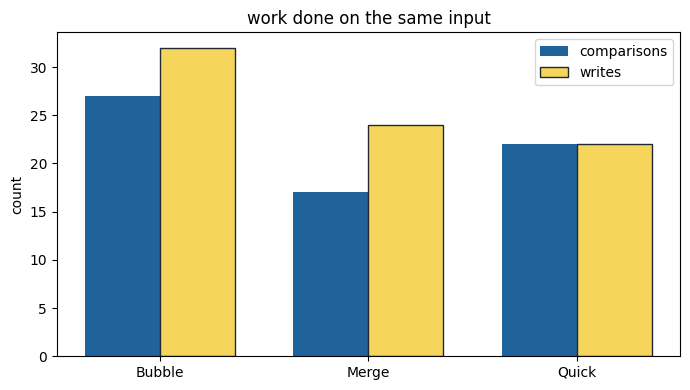

In [2]:
workshop = SortingWorkshop()
values = [8, 3, 7, 4, 9, 2, 6, 5]

bubble_result = workshop.bubble_sort(values)
merge_result = workshop.merge_sort(values)
quick_result = workshop.quick_sort(values)
results = [bubble_result, merge_result, quick_result]

for result in results:
    print(result.summary())

assert bubble_result.sorted_values == merge_result.sorted_values == quick_result.sorted_values
plot_algorithm_costs(results)

## 4. Replay Bubble Sort

Bubble sort is slow, but it is the easiest to see: compare neighbors, swap if they are out of order, repeat until no swaps are needed.

 1. start: [8, 3, 7, 4, 9, 2, 6, 5]
 2. compare positions 0 and 1: [8, 3, 7, 4, 9, 2, 6, 5]
 3. swap into order: [3, 8, 7, 4, 9, 2, 6, 5]
 4. compare positions 1 and 2: [3, 8, 7, 4, 9, 2, 6, 5]
 5. swap into order: [3, 7, 8, 4, 9, 2, 6, 5]
 6. compare positions 2 and 3: [3, 7, 8, 4, 9, 2, 6, 5]
 7. swap into order: [3, 7, 4, 8, 9, 2, 6, 5]
 8. compare positions 3 and 4: [3, 7, 4, 8, 9, 2, 6, 5]
 9. compare positions 4 and 5: [3, 7, 4, 8, 9, 2, 6, 5]
10. swap into order: [3, 7, 4, 8, 2, 9, 6, 5]
11. compare positions 5 and 6: [3, 7, 4, 8, 2, 9, 6, 5]
12. swap into order: [3, 7, 4, 8, 2, 6, 9, 5]
... 33 more steps


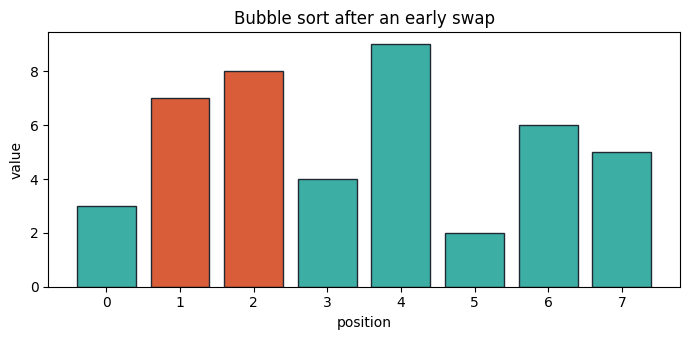

In [3]:
SortReplay(bubble_result).show(max_steps=12)
plot_sort_snapshot(bubble_result.steps[4], title="Bubble sort after an early swap")

## 5. Compare Divide and Conquer

Merge sort and quicksort both reduce the problem by splitting it.

- Merge sort splits first, then carefully merges sorted halves.
- Quicksort chooses a pivot, partitions around it, then sorts the partitions.

In [4]:
print("Merge sort replay")
SortReplay(merge_result).show(max_steps=12)
print()
print("Quick sort replay")
SortReplay(quick_result).show(max_steps=12)

Merge sort replay
 1. start: [8, 3, 7, 4, 9, 2, 6, 5]
 2.     merge [8] and [3] -> [3, 8]: [3, 8]
 3.     merge [7] and [4] -> [4, 7]: [4, 7]
 4.   merge [3, 8] and [4, 7] -> [3, 4, 7, 8]: [3, 4, 7, 8]
 5.     merge [9] and [2] -> [2, 9]: [2, 9]
 6.     merge [6] and [5] -> [5, 6]: [5, 6]
 7.   merge [2, 9] and [5, 6] -> [2, 5, 6, 9]: [2, 5, 6, 9]
 8. merge [3, 4, 7, 8] and [2, 5, 6, 9] -> [2, 3, 4, 5, 6, 7, 8, 9]: [2, 3, 4, 5, 6, 7, 8, 9]
 9. done: [2, 3, 4, 5, 6, 7, 8, 9]

Quick sort replay
 1. start: [8, 3, 7, 4, 9, 2, 6, 5]
 2. pivot 5: [3, 4, 2] | [5] | [8, 7, 9, 6]: [3, 4, 2, 5, 8, 7, 9, 6]
 3.   pivot 2: [] | [2] | [3, 4]: [2, 3, 4]
 4.     pivot 4: [3] | [4] | []: [3, 4]
 5.   pivot 6: [] | [6] | [8, 7, 9]: [6, 8, 7, 9]
 6.     pivot 9: [8, 7] | [9] | []: [8, 7, 9]
 7.       pivot 7: [] | [7] | [8]: [7, 8]
 8. done: [2, 3, 4, 5, 6, 7, 8, 9]


## 6. Binary Search: The Payoff

Binary search only works because the list is sorted.

Each step checks the middle value, then discards either the left half or the right half.

In [5]:
sorted_values = list(merge_result.sorted_values)
search_result = workshop.binary_search(sorted_values, target=7)

print(search_result.summary())
for step_number, step in enumerate(search_result.steps, start=1):
    print(f"{step_number}. {step.describe()}")

target 7 -> index 5 in 2 comparisons
1. low=0, high=7, mid=3, guess=5: too small; keep right half
2. low=4, high=7, mid=5, guess=7: found


## 7. Complexity Snapshot

| Algorithm | Main idea | Typical time | Extra memory | Good lesson |
| --- | --- | --- | --- | --- |
| Bubble sort | Swap neighbors | $O(n^2)$ | $O(1)$ | Simple does not mean scalable |
| Merge sort | Split and merge | $O(n \log n)$ | $O(n)$ | Predictable divide-and-conquer |
| Quicksort | Pivot and partition | average $O(n \log n)$ | depends on implementation | Fast practical sorting |
| Binary search | Cut sorted range in half | $O(\log n)$ | $O(1)$ | Sorted data unlocks speed |

<details>
<summary>Why binary search is logarithmic</summary>

If a list has 1,000 items, binary search does not need 1,000 guesses. It checks about $\log_2(1000) \approx 10$ middle points because every comparison halves the remaining range.
</details>

## Try This

1. Change `values` to a nearly sorted list. Which algorithm benefits most?
2. Change `values` to a reverse-sorted list. What happens to bubble sort?
3. Search for a number that is not in the list. How many binary-search steps happen?
4. Change quicksort's pivot rule in the code. Does the number of comparisons change?

Keep the experiment small: make one change, predict the result, run it, then explain the difference in one sentence.

## Visual Trace + Rigor Studio

**Problem frame.** Turn unordered values into ordered structure using comparisons.

**Interactive animation target.** Animate comparisons, swaps, settled regions, and operation counts on a bar chart.

**Correctness handle.** Each pass increases the portion of the array known to be in final sorted order.

**Complexity handle.** Compare best, average, and worst cases instead of giving one number.

**Failure mode to test.** A visually sorted-looking prefix may still hide a disordering element later in the array.

**Studio task.** Build a trace for another sorting algorithm and compare its visual rhythm with bubble sort.


In [ ]:
from pathlib import Path
import sys
from IPython.display import display

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, bubble_sort_trace, render_array_bars, render_trace_table

trace = bubble_sort_trace([5, 1, 4, 2, 8])
display(render_trace_table(trace))
AlgorithmPlayer(trace, render_array_bars).display()
